# multiagent 

In [34]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

In [35]:
import os
from dotenv import load_dotenv
load_dotenv() # to load env variables from .env file

os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')

In [36]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

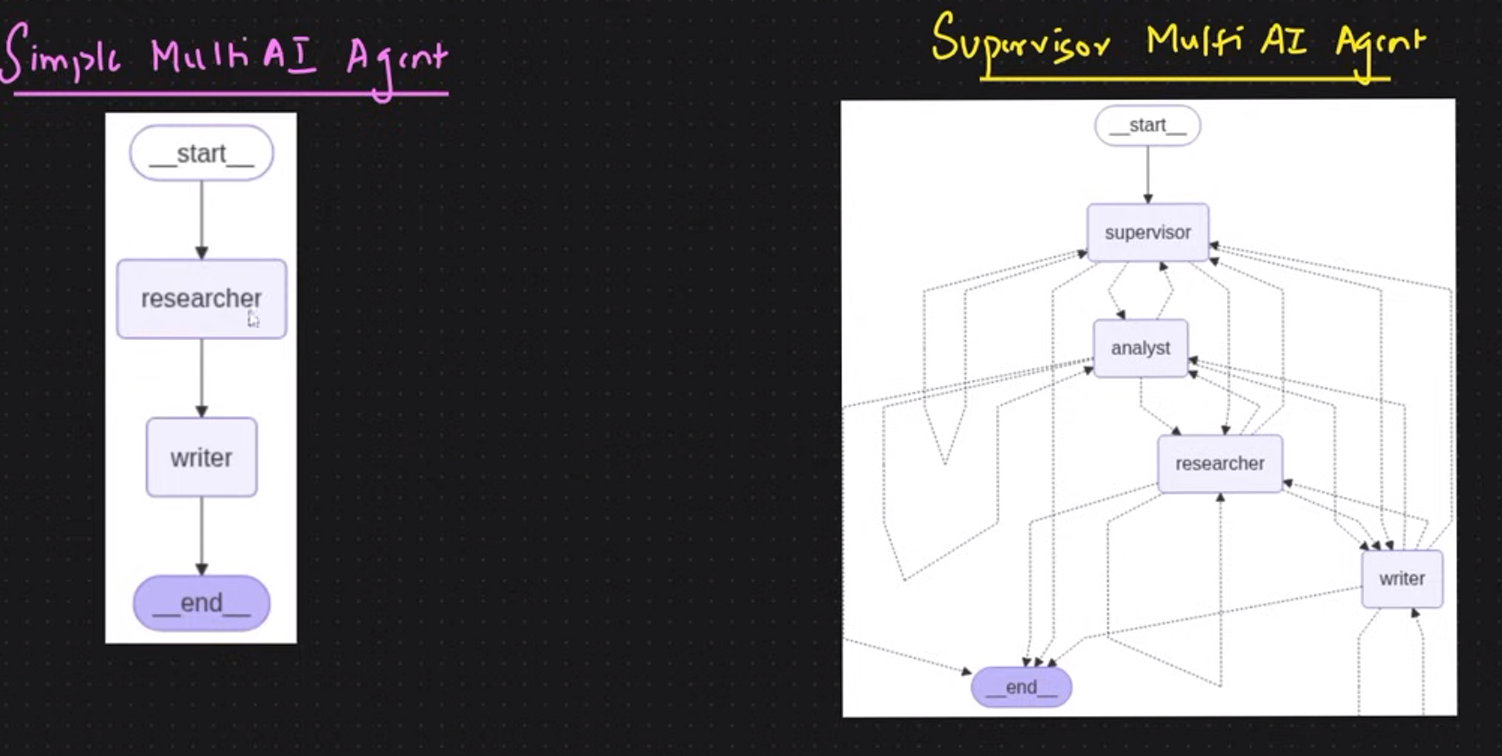

In [37]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):  # inherit from MessagesState
    next_agent: str

In [38]:
# create sample tool
@tool
def search_web(query:str) -> str:
    """search the web for information"""
    # using tavily web search tool to search the web
    search=TavilySearchResults(max_results=3)
    results=search.invoke(query)
    return str(results)

@tool
def write_summary(content:str) -> str:
    """write a summary of the content"""
    # using groq to write a summary of the content
    summary=f"summary of findings:\n\n{content[:500]}..."
    return summary

In [39]:
from langchain.chat_models import init_chat_model
llm=init_chat_model('groq:llama-3.1-8b-instant')
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020592BCBA10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020592F24E30>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [40]:

# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    # Add system message for context
    system_msg = SystemMessage(
        content="You are a research assistant. Use the search_web tool to find"
    )

    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [41]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""

    messages = state["messages"]

    # Add system message
    system_msg = SystemMessage(
        content="You are a technical writer. Review the conversation and create"
    )

    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)

    return {
        "messages": [response],
        "next_agent": "end"
    }

In [42]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""

    messages = state["messages"]
    last_message = messages[-1]

    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    # No tools to execute
    return state

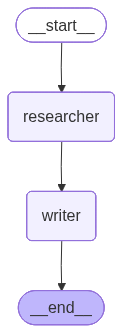

In [43]:
# build graph
workflow = StateGraph(MessagesState)

# adding nodes to the graph

workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# defining flwow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow= workflow.compile()


final_workflow

In [44]:
response=final_workflow.invoke({"messages":"research about usecase of agentic ai in business"})

In [45]:
response["messages"][-1].content

' \n\n**Research on Agentic AI in Business Use Cases**\n\nAgentic AI refers to artificial intelligence that can perceive its environment, prioritize goals, and take actions to achieve them. This technology has the potential to revolutionize various aspects of business operations. Here are some use cases of agentic AI in business:\n\n### 1. **Virtual Assistants**\n\nAgentic AI can be integrated with virtual assistants to create more intelligent and proactive support systems. These assistants can learn employees\' preferences and adapt to their needs, automating routine tasks and freeing up more time for strategic work.\n\n### 2. **Predictive Maintenance**\n\nAgentic AI can be used to predict equipment failures and schedule maintenance accordingly. This can lead to reduced downtime, increased productivity, and lower maintenance costs.\n\n### 3. **Sales and Marketing**\n\nAgentic AI can help sales and marketing teams by analyzing customer data, identifying patterns, and making predictions

# Supervised Multi AI agent architecture 

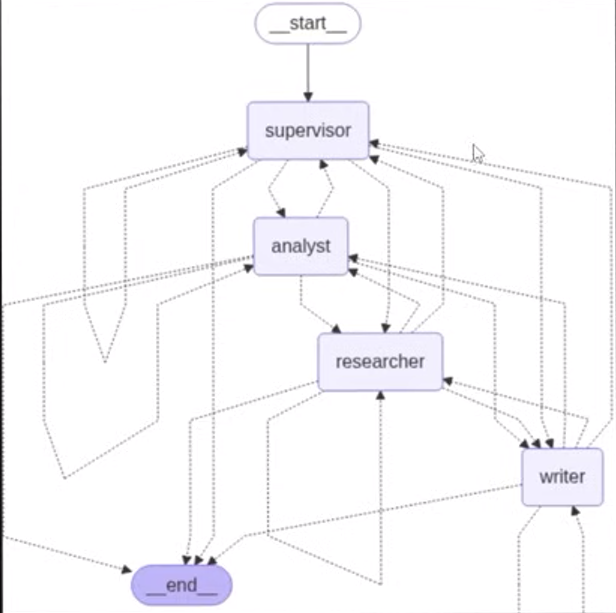

In [47]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [49]:
# ================================
# State Definition
# ================================

class SupervisorState(MessagesState):
    """State for the supervisor multi-agent system"""
    
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""
    

In [62]:
# creating supervisor change
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:

1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}  
         
Respond with ONLY the agent name (Researcher, Analyst, Writer) or "DONE".
         """),
         ("human", "{task}")
    ])

    return supervisor_prompt | llm 
         
         

In [63]:

def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""

    messages = state["messages"]
    task = messages[-1].content if messages else "No task"

    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))

    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })

    # parse decision 
    decision_text=decision.content.strip().lower()
    print(decision_text)

    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📄 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📄 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📄 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg="Supervisor: Task seems completed"
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }


In [64]:
# agent -1 Researcher agent
 
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""

    task = state.get("current_task", "research topic")

    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

Include:
1. Key facts and background
2. Current trends or developments
3. Important statistics or data points
4. Notable examples or case studies

Be concise but thorough."""
    
    # Get results from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content

    # creating agent message
    agent_message = f"🔍 Researcher: I've gathered the following information on '{task}':\n\n{research_data[:500]}..."

    return{
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [65]:
# agent 2: Analyst
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "")

    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. key insights and patterns
2. strategic implications
3. risk and opportunities
4. recommendations 
Focus on actionable insights relaetd to the task: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis= analysis_response.content

    # create agent message  
    agent_message = f"📊 Analyst: Based on the research, here are my insights:\n\n{analysis[:500]}..."

    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [66]:
# Agent 3: Writer (using Groq)
# ============================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise.
"""

    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content

    # create final formated report
    final_report = f"""
    📑 Final Report
    {'='*50}  
    Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}
    Topic: {task}
    {'='*50} 

    {report}

    {'='*50}
    Report Compiled by multi Ai-agent system by groq
    """
    return {
        "messages": [AIMessage(content=f"🖋️ Writer: Report created successfully!")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

# router function

In [67]:
def router(state:SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Route to the next agent based on state"""

    next_agent= state.get("next_agent", "supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END
    
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
    
    return "supervisor"

In [68]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END    
        }
    )

graph=workflow.compile()

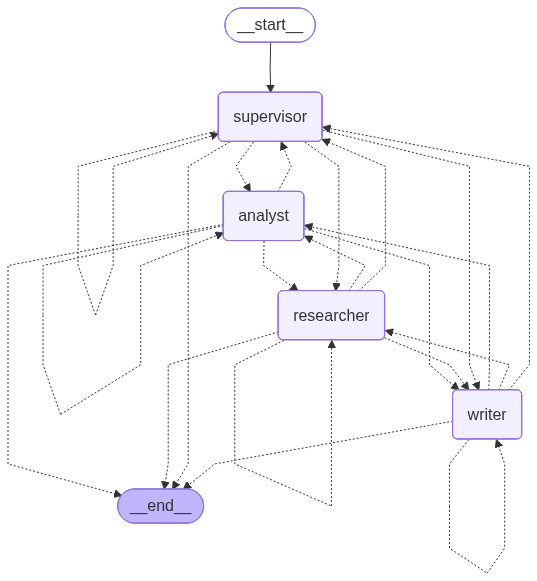

In [69]:
graph

In [ ]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

researcher
researcher
researcher
analyst
writer


{'messages': [AIMessage(content="📄 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='7a7cb48b-0b63-46be-b310-92eadf4981a4', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've gathered the following information on 'No task':\n\nIt appears you haven't specified a task for me to provide information on. Please provide a specific task or topic you'd like to know more about, and I'll be happy to assist you in the following format:\n\n1. Key facts and background\n2. Current trends or developments\n3. Important statistics or data points\n4. Notable examples or case studies\n\nThis will allow me to provide you with a comprehensive and concise overview of the topic you're interested in....", additional_kwargs={}, response_metadata={}, id='aa67c821-7c1b-4335-9d9c-a19fb52be7ed', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="📄 Supervisor: Let's start with research. Assigning to Researcher..."

In [71]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

researcher
analyst
analyst
writer


In [72]:
response["final_report"]

'\n    📑 Final Report\n    ==================================================  \n    Generated : 2026-04-23 21:10\n    Topic: 📊 Analyst: Based on the research, here are my insights:\n\nLet\'s proceed with the hypothetical dataset related to "E-commerce Sales and Customer Satisfaction".\n\n**1. Key Facts and Background**\n\n* **Brief Overview:** E-commerce sales refer to the revenue generated by online transactions, while customer satisfaction measures the level of happiness and loyalty customers experience when interacting with an e-commerce platform.\n* **Historical Context:** The rise of e-commerce has led to increased competition and changing consumer behaviors, making customer s...\n    ================================================== \n\n    **Executive Report: Enhancing E-commerce Sales through Customer Satisfaction**\n\n**1. Executive Summary**\n\nAs the e-commerce landscape continues to evolve, businesses are facing increased pressure to deliver exceptional customer experienc

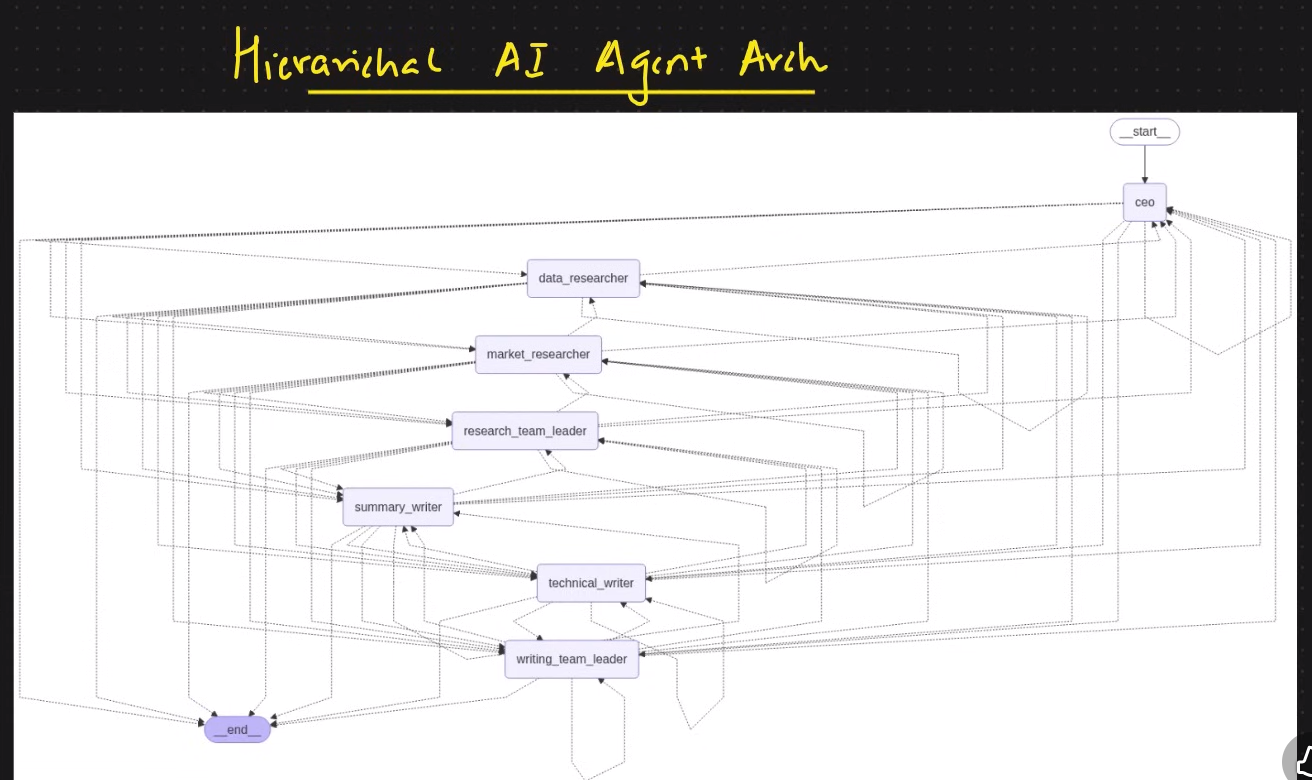

In [73]:
# remaining

# Simple Hierarchical Multi-Agent System with Groq

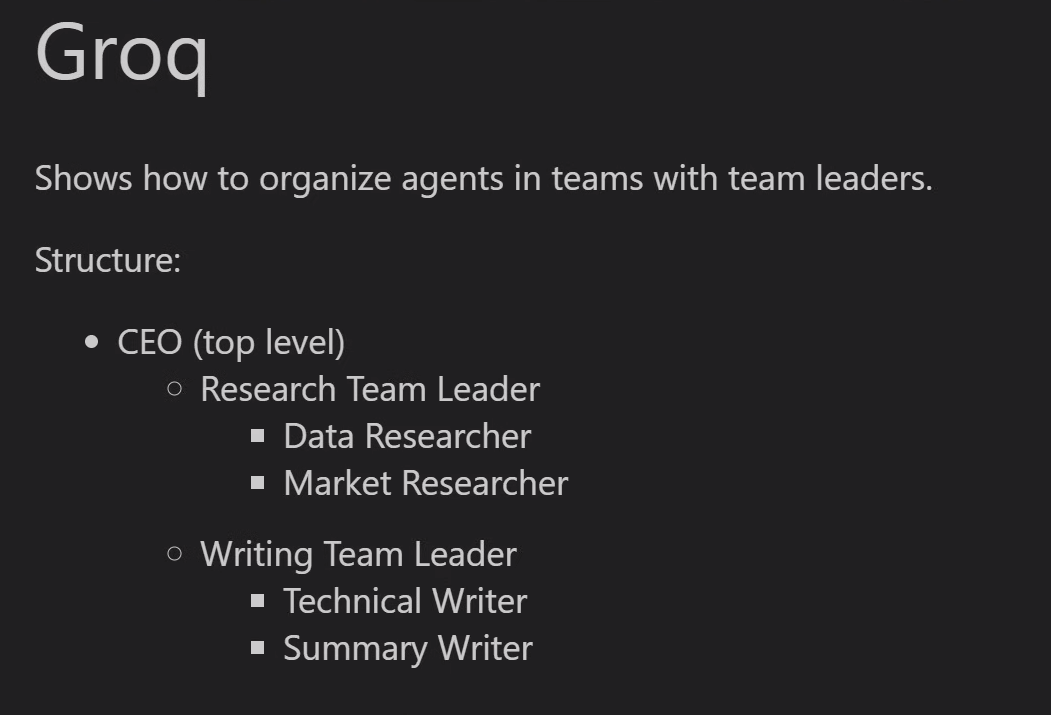